# LeNet-5 Architecture Implementation

This notebook contains the PyTorch implementation of the LeNet-5 convolutional neural network, modified to use Max Pooling and ReLU activation.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1: 1 input image channel, 6 output channels, 5x5 square convolution
        self.conv1 = nn.Conv2d(1, 8, kernel_size=5, stride=1, padding=2)
        # S2: Max pooling layer with 2x2 kernel and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C3: 6 input channels, 16 output channels, 5x5 square convolution
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5)
        # S4: Max pooling layer with 2x2 kernel and stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C5: 16 input channels, 120 output channels, 5x5 square convolution
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        # F6: Fully connected layer
        self.fc1 = nn.Linear(120, 84)
        # Output level: Fully connected layer
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Visualizing Initial Filters

Initial weights of the first convolutional layer (`conv1`).

Aqui será plotado os filtros da rede neural

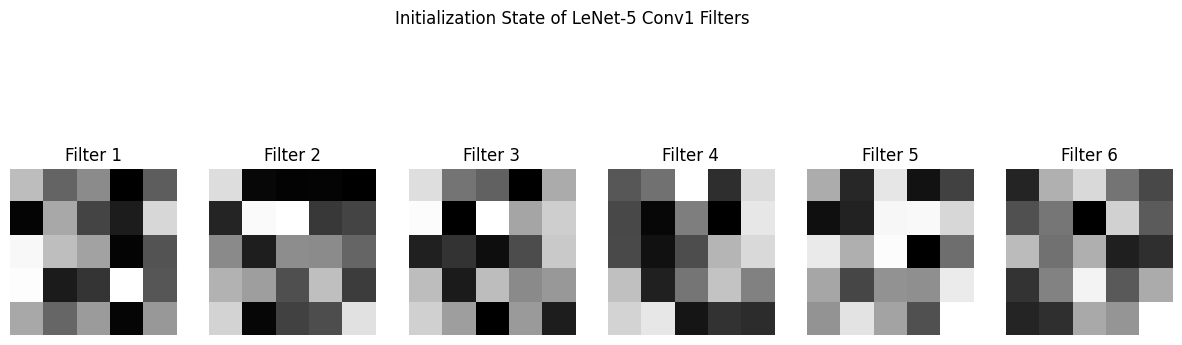

In [2]:
import matplotlib.pyplot as plt

model = LeNet5(num_classes=10)
filters = model.conv1.weight.detach()

fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(filters[i, 0].cpu(), cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')
plt.suptitle('Initialization State of LeNet-5 Conv1 Filters')
plt.show()

## Loading and Visualizing MNIST Dataset

Código de obtenção do dataset de treinamento no caso MNIST e plotagem de algumas imagens de exemplo

100.0%
100.0%
100.0%
100.0%


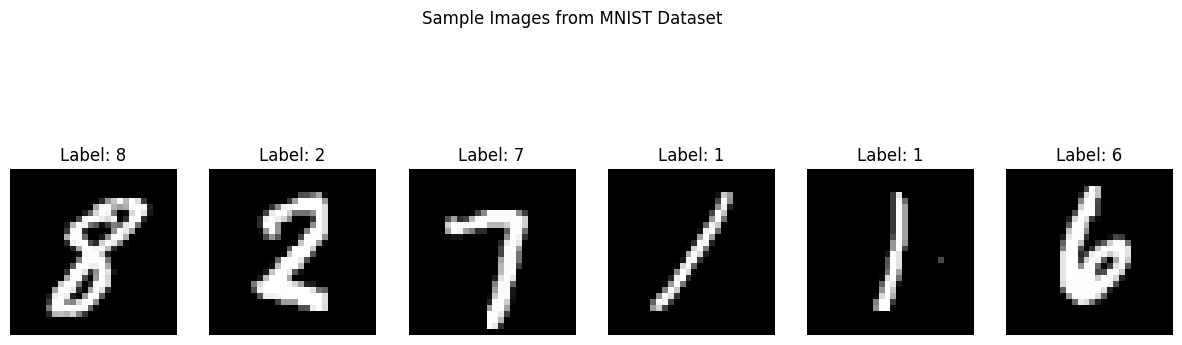

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.suptitle('Sample Images from MNIST Dataset')
plt.show()

## Visualizing Feature Maps (Layer 1 Activations)

Let's see what features the first convolutional layer (`conv1`) extracts from a sample image. We'll pass an image through the first layer and plot the resulting 6 feature maps.

Visualizing feature maps for digit: 5


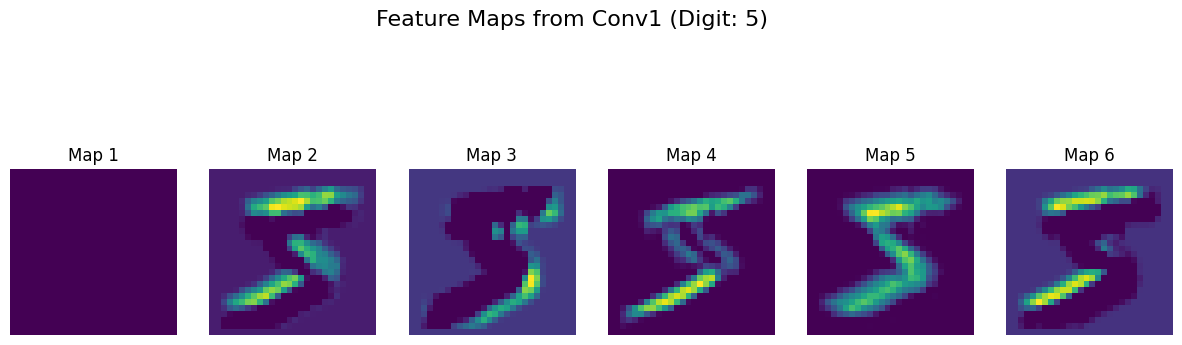

In [9]:
# Get a single sample image from the dataset
sample_image, sample_label = train_dataset[0]
sample_image = sample_image.unsqueeze(0) # Add batch dimension [1, 1, 28, 28]

# Passage through the first layer ONLY (Conv1 + ReLU)
model.eval()
with torch.no_grad():
    # Move sample to the same device as the model (if applicable)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    sample_image = sample_image.to(device)
    
    feature_maps = F.relu(model.conv1(sample_image))

# Move back to CPU for plotting
feature_maps = feature_maps.cpu().squeeze(0) # [6, 28, 28]

print(f"Visualizing feature maps for digit: {sample_label}")

# Plotting
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i in range(6):
    axes[i].imshow(feature_maps[i], cmap='viridis')
    axes[i].set_title(f'Map {i+1}')
    axes[i].axis('off')

plt.suptitle(f'Feature Maps from Conv1 (Digit: {sample_label})', fontsize=16)
plt.show()

## Training the Network

Setting up the training loop with CrossEntropyLoss and Adam optimizer. We'll use a larger batch size for efficient training.

In [ ]:
import torch.optim as optim

# Device configuration (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Hyperparameters
learning_rate = 0.001
batch_size = 64 # Quantidade de imagens que serão carregadas ao mesmo tempo
num_epochs = 5 # quantidade de vezes que o treinamento irá passar pelo dataset

# Update DataLoader with larger batch size for training
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loss and optimizer
criterion = nn.CrossEntropyLoss() # Forma de correção da rede neural
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#O Otimizador é quem irá otimizar o aprendizado da IA

# Training loop
print(f'Training on {device}...')
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        # os loss são os erros, tipo uma nota de quao bem está a IA
        #por isso são passados as informações das asídas comparando com o que deveria ser

        # Backward and optimize
        optimizer.zero_grad() # fazemos o otimizador zerar,  para nn estourar a memória
        loss.backward()
        optimizer.step() # Efetiva o aprendizado da rede

        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

print("Training finished!")

Training on cpu...
Epoch [1/5], Step [100/938], Loss: 0.3912
Epoch [1/5], Step [200/938], Loss: 0.4986
Epoch [1/5], Step [300/938], Loss: 0.1495
Epoch [1/5], Step [400/938], Loss: 0.0988
Epoch [1/5], Step [500/938], Loss: 0.2405
Epoch [1/5], Step [600/938], Loss: 0.0523
Epoch [1/5], Step [700/938], Loss: 0.2716
Epoch [1/5], Step [800/938], Loss: 0.0220
Epoch [1/5], Step [900/938], Loss: 0.1334
Epoch [2/5], Step [100/938], Loss: 0.0533
Epoch [2/5], Step [200/938], Loss: 0.1063
Epoch [2/5], Step [300/938], Loss: 0.0307
Epoch [2/5], Step [400/938], Loss: 0.1697
Epoch [2/5], Step [500/938], Loss: 0.0360
Epoch [2/5], Step [600/938], Loss: 0.0127
Epoch [2/5], Step [700/938], Loss: 0.0968
Epoch [2/5], Step [800/938], Loss: 0.0564
Epoch [2/5], Step [900/938], Loss: 0.0520
Epoch [3/5], Step [100/938], Loss: 0.0169
Epoch [3/5], Step [200/938], Loss: 0.1205
Epoch [3/5], Step [300/938], Loss: 0.0315
Epoch [3/5], Step [400/938], Loss: 0.1107
Epoch [3/5], Step [500/938], Loss: 0.0061
Epoch [3/5], St

## Evaluating the Performance

Now we'll load the test dataset and calculate the overall accuracy of our trained model.

Fazendo a avaliação da IA com os valores que ela nunca viu antes, batchs com imagens ainda não vistas

In [5]:
# Load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Set model to evaluation mode
model.eval()

correct = 0
total = 0
misclassified_images = []
misclassified_labels = []
predicted_labels = []

# No gradient calculation needed during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Collect misclassified examples
        misclassified_mask = (predicted != labels)
        if misclassified_mask.any():
            misclassified_images.append(images[misclassified_mask].cpu())
            misclassified_labels.append(labels[misclassified_mask].cpu())
            predicted_labels.append(predicted[misclassified_mask].cpu())

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')

Accuracy of the network on the 10,000 test images: 98.96%


## Visualizing Misclassified Images

Let's see where the model gets confused by plotting some of the misclassified images from the test set.

Visualizando os números em que a rede errou

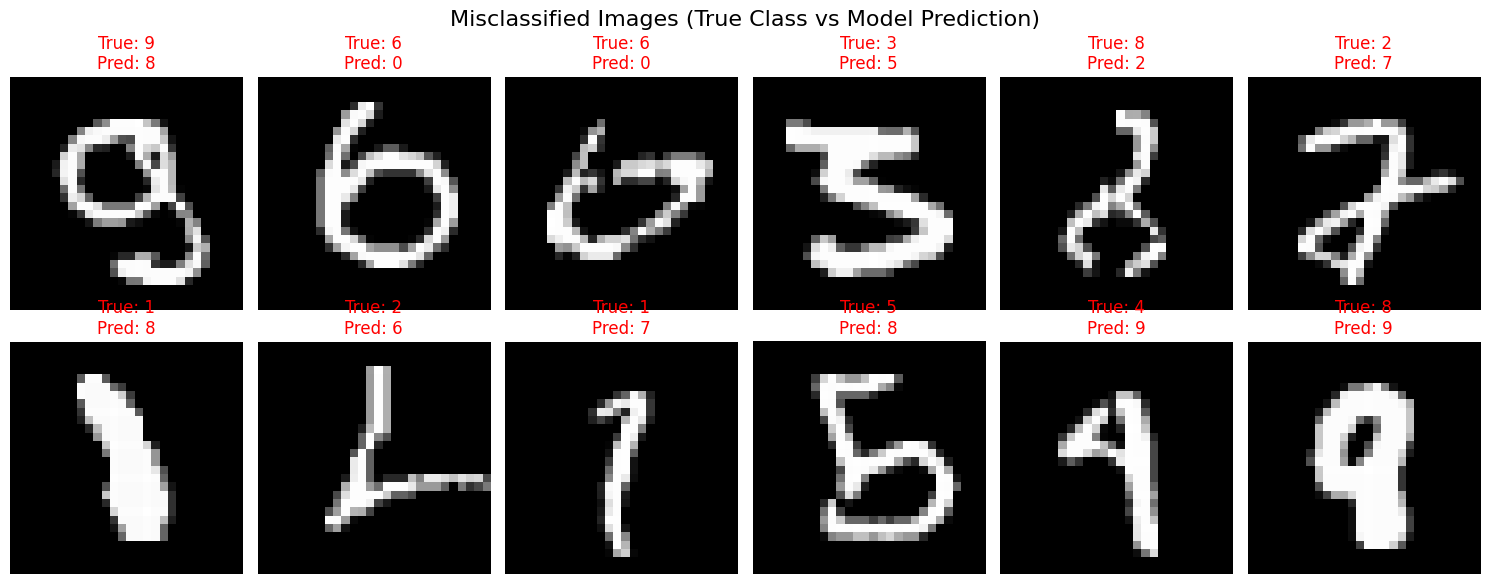

In [6]:
# Concatenate all collected misclassified samples
misclassified_images = torch.cat(misclassified_images)
misclassified_labels = torch.cat(misclassified_labels)
predicted_labels = torch.cat(predicted_labels)

# Display first 12 misclassified images
num_to_show = min(12, len(misclassified_images))
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(num_to_show):
    ax = axes[i // 6, i % 6]
    ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {misclassified_labels[i].item()}\nPred: {predicted_labels[i].item()}', color='red')
    ax.axis('off')

plt.suptitle('Misclassified Images (True Class vs Model Prediction)', fontsize=16)
plt.tight_layout()
plt.show()

## Saving the Model

Best practice in PyTorch is to save the `state_dict` which contains only the learned parameters.

In [7]:
import os

# Create 'weights' directory if it doesn't exist
os.makedirs('weights', exist_ok=True)

# Set save path
PATH = './weights/lenet5_mnist.pth'

torch.save(model.state_dict(), PATH)
print(f"Model saved to {PATH}")

Model saved to ./weights/lenet5_mnist.pth


## Loading the Model for Later Use

Here's how to recreate the model and load the saved weights.

In [ ]:
# 1. Create a new instance of the model
model = LeNet5(num_classes=10)

# 2. Load the state dictionary
model.load_state_dict(torch.load('./weights/lenet5_mnist.pth'))

# 3. Set to evaluation mode if you're using it for inference
model.eval()

print("New model instance created and weights loaded successfully!")

New model instance created and weights loaded successfully!
